Mounted at /content/drive
Базовый F1-Score: 0.7294
Базовый Precision-Recall AUC: 0.7802


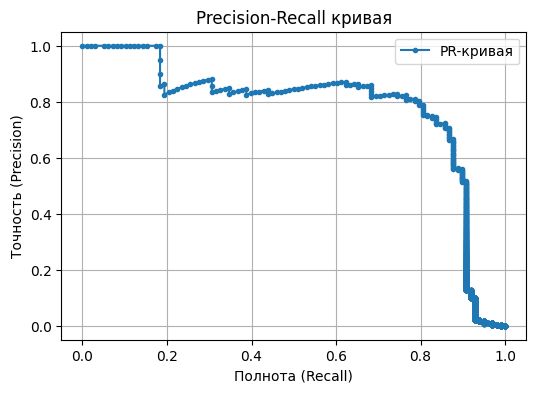

In [ ]:
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

drive.mount('/content/drive')
path = "/content/drive/MyDrive/creditcard.csv"
df = pd.read_csv(path)
df.head()
X = df.drop('Class', axis=1)
Y = df['Class']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=11, stratify=Y)

scaler = StandardScaler()
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

model = LogisticRegression(random_state=52,max_iter=1000)
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

f1 = f1_score(Y_test, y_pred)
precision, recall, _ = precision_recall_curve(Y_test, y_proba)
pr_auc = auc(recall, precision)

print(f"Базовый F1-Score: {f1:.4f}")
print(f"Базовый Precision-Recall AUC: {pr_auc:.4f}")
plt.figure(figsize=(6,4))
plt.plot(recall, precision, marker='.', label='PR-кривая')
plt.xlabel('Полнота (Recall)')
plt.ylabel('Точность (Precision)')
plt.title('Precision-Recall кривая')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

results = {}

model_weighted = LogisticRegression(random_state=52, max_iter=1000, class_weight="balanced")
model_weighted.fit(X_train, Y_train)

y_weight_pred = model_weighted.predict(X_test)
y_weight_proba = model_weighted.predict_proba(X_test)[:,1]

precision_w, recall_w, _ = precision_recall_curve(Y_test, y_weight_proba)
results['Class Weighting'] = {
    'F1-Score': f1_score(Y_test, y_weight_pred),
    'Precision-Recall AUC' : auc(recall_w, precision_w)
}

smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

model_smote = LogisticRegression(random_state=52, max_iter=1000)
model_smote.fit(X_train_smote, Y_train_smote)

y_smote_pred = model_smote.predict(X_test)
y_smote_proba = model_smote.predict_proba(X_test)[:,1]

precision_smote, recall_smote, _ = precision_recall_curve(Y_test, y_smote_proba)
results['SMOTE'] = {
    'F1-Score' : f1_score(Y_test, y_smote_pred),
    'Precision-Recall AUC' : auc(recall_smote, precision_smote)
}

random_under_sampler = RandomUnderSampler(random_state=52)
X_undersampling_train, Y_undersampling_train = random_under_sampler.fit_resample(X_train, Y_train)

model_undersampling = LogisticRegression(random_state=52, max_iter=1000)
model_undersampling.fit(X_undersampling_train, Y_undersampling_train)

y_undersampling_pred = model_undersampling.predict(X_test)
y_undersampling_proba = model_undersampling.predict_proba(X_test)[:,1]

precision_undersampling, recall_undersampling, _ = precision_recall_curve(Y_test, y_undersampling_proba)
results['RandomUnderSampling'] = {
    'F1-Score' : f1_score(Y_test, y_undersampling_pred),
    'Precision-Recall AUC' : auc(recall_undersampling, precision_undersampling)
}

comparison_df = pd.DataFrame(results).T
print(comparison_df)



                     F1-Score  Precision-Recall AUC
Class Weighting      0.123269              0.759503
SMOTE                0.113402              0.761363
RandomUnderSampling  0.069903              0.548365


In [ ]:
for weight in [1, 2, 3, 5, 10, 20, 30, 50, 100]:
    model = LogisticRegression(class_weight={0:1, 1:weight}, random_state=42, max_iter=1000)
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    y_weight_proba2 = model.predict_proba(X_test)[:,1]
    precision_w2, recall_w2, _ = precision_recall_curve(Y_test, y_weight_proba2)
    print(f"Вес мошенников = {weight}, F1 = {f1_score(Y_test, y_pred):.4f}, Precision-Recall AUC: {auc(recall_w2, precision_w2):.4f}")

Вес мошенников = 1, F1 = 0.7294, Precision-Recall AUC: 0.7802
Вес мошенников = 2, F1 = 0.7956, Precision-Recall AUC: 0.7809
Вес мошенников = 3, F1 = 0.7958, Precision-Recall AUC: 0.7762
Вес мошенников = 5, F1 = 0.7980, Precision-Recall AUC: 0.7755
Вес мошенников = 10, F1 = 0.8020, Precision-Recall AUC: 0.7689
Вес мошенников = 20, F1 = 0.7793, Precision-Recall AUC: 0.7621
Вес мошенников = 30, F1 = 0.7179, Precision-Recall AUC: 0.7572
Вес мошенников = 50, F1 = 0.6056, Precision-Recall AUC: 0.7511
Вес мошенников = 100, F1 = 0.3964, Precision-Recall AUC: 0.7362


In [ ]:
for ratio in [0.005, 0.008, 0.01, 0.02, 0.04, 0.06, 0.08, 0.1, 0.2, 0.3]:
  new_model_smote = LogisticRegression(random_state=42, max_iter=1000)
  new_model_under = LogisticRegression(random_state=42, max_iter=1000)
  rus = RandomUnderSampler(sampling_strategy=ratio, random_state=42)
  X_train_under, Y_train_under = rus.fit_resample(X_train, Y_train)
  smote = SMOTE(sampling_strategy=ratio, random_state=42)
  X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)
  new_model_smote.fit(X_train_smote, Y_train_smote)
  new_model_under.fit(X_train_under, Y_train_under)
  y_pred_sm = new_model_smote.predict(X_test)
  y_proba_sm = new_model_smote.predict_proba(X_test)[:,1]
  y_pred_un = new_model_under.predict(X_test)
  y_proba_un = new_model_under.predict_proba(X_test)[:,1]
  precision_sm, recall_sm, _ = precision_recall_curve(Y_test, y_proba_sm)
  precision_un, recall_un, _ = precision_recall_curve(Y_test, y_proba_un)
  print(f"SMOTE, соотношение 1:{int(1/ratio)}, F1 = {f1_score(Y_test, y_pred_sm):.4f}, Precision-Recall AUC: {auc(recall_sm, precision_sm):.4f}")
  print(f"RandomUnderSampler, соотношение 1:{int(1/ratio)}, F1 = {f1_score(Y_test, y_pred_un):.4f}, Precision-Recall AUC: {auc(recall_un, precision_un):.4f}")


SMOTE, соотношение 1:200, F1 = 0.7872, Precision-Recall AUC: 0.7744
RandomUnderSampler, соотношение 1:200, F1 = 0.7853, Precision-Recall AUC: 0.7661
SMOTE, соотношение 1:125, F1 = 0.8020, Precision-Recall AUC: 0.7729
RandomUnderSampler, соотношение 1:125, F1 = 0.7900, Precision-Recall AUC: 0.7669
SMOTE, соотношение 1:100, F1 = 0.7980, Precision-Recall AUC: 0.7686
RandomUnderSampler, соотношение 1:100, F1 = 0.7861, Precision-Recall AUC: 0.7644
SMOTE, соотношение 1:50, F1 = 0.7960, Precision-Recall AUC: 0.7631
RandomUnderSampler, соотношение 1:50, F1 = 0.7902, Precision-Recall AUC: 0.7623
SMOTE, соотношение 1:25, F1 = 0.7721, Precision-Recall AUC: 0.7588
RandomUnderSampler, соотношение 1:25, F1 = 0.6942, Precision-Recall AUC: 0.7455
SMOTE, соотношение 1:16, F1 = 0.6967, Precision-Recall AUC: 0.7542
RandomUnderSampler, соотношение 1:16, F1 = 0.5714, Precision-Recall AUC: 0.7623
SMOTE, соотношение 1:12, F1 = 0.6277, Precision-Recall AUC: 0.7525
RandomUnderSampler, соотношение 1:12, F1 = 0.

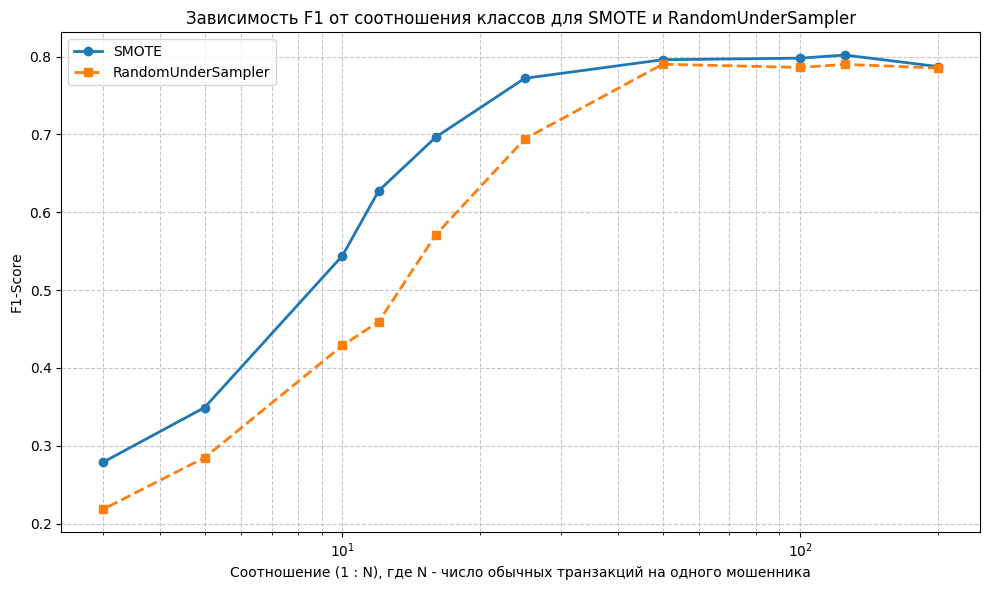

In [ ]:
# Данные для SMOTE (соотношения и соответствующие F1)
smote_N = [200, 125, 100, 50, 25, 16, 12, 10, 5, 3]
smote_f1 = [0.7872, 0.8020, 0.7980, 0.7960, 0.7721, 0.6967, 0.6277, 0.5443, 0.3492, 0.2789]

# Данные для RandomUnderSampler
under_N = [200, 125, 100, 50, 25, 16, 12, 10, 5, 3]
under_f1 = [0.7853, 0.7900, 0.7861, 0.7902, 0.6942, 0.5714, 0.4595, 0.4289, 0.2848, 0.2184]

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(smote_N, smote_f1, marker='o', linestyle='-', linewidth=2, label='SMOTE')
plt.plot(under_N, under_f1, marker='s', linestyle='--', linewidth=2, label='RandomUnderSampler')

# Настройка осей (логарифмическая шкала по X, чтобы лучше видеть детали при больших N)
plt.xscale('log')
plt.xlabel('Соотношение (1 : N), где N - число обычных транзакций на одного мошенника')
plt.ylabel('F1-Score')
plt.title('Зависимость F1 от соотношения классов для SMOTE и RandomUnderSampler')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

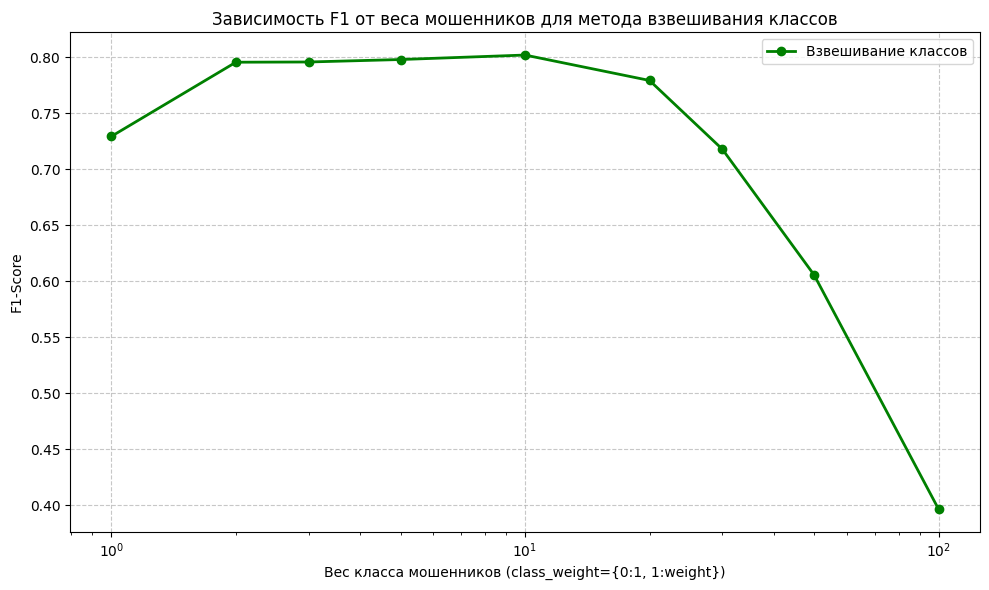

In [ ]:
weights = [1, 2, 3, 5, 10, 20, 30, 50, 100]
f1_scores = [0.7294, 0.7956, 0.7958, 0.7980, 0.8020, 0.7793, 0.7179, 0.6056, 0.3964]

plt.figure(figsize=(10, 6))
plt.plot(weights, f1_scores, marker='o', linestyle='-', linewidth=2, color='green', label='Взвешивание классов')
plt.xscale('log')  # логарифмическая шкала, чтобы лучше видеть детали при малых весах
plt.xlabel('Вес класса мошенников (class_weight={0:1, 1:weight})')
plt.ylabel('F1-Score')
plt.title('Зависимость F1 от веса мошенников для метода взвешивания классов')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('f1_vs_weight.png', dpi=300)
plt.show()